# Constraining SLD: Mass conservation

In some cases, we may want to constrain sld parameters via the integrals of layers in the `vfp` when we want to conserve the amount of a material. In this case we apply this constraint across multiple sample measurements (e.g. for a polymer film containing 2 species that changes on annealing).

In this example, we show how to use the `sld_constraint` parameter that can be supplied to `vfp.VFP`, `vfp.refnxVFP` and `vfp.refl1dVFP` to achieve such a constraint.

In [1]:
import numpy as np
import pathlib
import os
import matplotlib.pyplot as plt
import periodictable

from refnx.analysis import GlobalObjective, Parameter, Objective, CurveFitter
from refnx.reflect import ReflectModel, SLD
from refnx.dataset import ReflectDataset

import vfp

## A contrived example

We'll build a model where we have a substrate (silicon, with a silicon oxide layer) submerged in a water, with 2 different polymer layers. On applying external field (e.g. annealing) the polymer layers can mix together. In this case we will model this as being 3 layers. To make it a better constraint example, we assume there is some mixing initially too.

    Si | SiOx | Polymer A-rich | Polymer B-rich

    Si | SiOx | Polymer A-rich | Mixed A + B | Polymer B-rich

This intermixing could occur through a variety of structures, this is just one example for illustrative purposes.

In this case, we assume that the SLDs of A and B are known.


## Conserving the polymer mass

The total of the $j^{th}$ component in the initial state is given by the integral of the volume fraction of each layer ($\int{\Phi_{j}\left(z\right) \mathrm{d}z}$), scaled by the volume fraction of that component in the layer ($\phi_{j}\left(z\right)$).

For the case outlined here, that means from the initial state:

$$ T_{A}= \phi_{1} * \int{\Phi_{1}\left(z\right) \mathrm{d}z} + \phi_{2} * \int{\Phi_{2}\left(z\right) \mathrm{d}z}, $$
$$ T_{B}= (1-\phi_{1}) * \int{\Phi_{1}\left(z\right) \mathrm{d}z} + (1-\phi_{2}) * \int{\Phi_{2}\left(z\right) \mathrm{d}z}, $$

For simplicity we will use:

$$ I_{j} = \int{\Phi_{j}\left(z\right) \mathrm{d}z} $$

i.e. we start from $ T_{A} = I_{1} * \phi_{1} + I_{2} * \phi_{2}$ and $ T_{B} = I_{1} * (1- \phi_{1}) + I_{2} * (1 - \phi_{2})$

Then after annealing we now have a new set of layers and to avoid confusion will call these 3, 4 and 5.
$$ T_{A} = I_{3} * \phi_{3} + I_{4} * \phi_{4} + I_{5} * \phi_{5}, $$
$$ T_{B} = I_{3} * (1 - \phi_{3}) + I_{4} * (1 - \phi_{4}) + I_{5} * \phi_{5}, $$

Now we need to decide how best to constrain the model so that the total A and total B are equivalent before and after the annealing. There are several options here and the best parameritisation will likely depend on the application. In this case, we choose that the total_A and total_B are fittable parameters alongside the volume fractions of all but one of the layers for each state. This remaining volume fraction will be determined from the above relationships. Here we choose the volume fractions of layers 2 and 4 to be calculated.

Rearranging the first two equations gives:
$$ \phi_{2} = \frac{T_{A} - I_{1}\phi_{1}}{T_{A} + T_{B} - I_{1}},$$

and rearranging the second two equations gives:
$$ \phi_{4} = \frac{T_{A} - I_{3}\phi_{3} - I_{5}\phi_{5}}{T_{A} + T_{B} - I_{3} - I_{5}},$$

#### DOES THIS NEED TO INCLUDE SLD's? For the calculation but also for setting total_A and total_B as parameters?

Then the SLD for layers 2 and 4 will be calculated from these volume fractions and the individual polymer SLDs ($\rho_{j}$):
$$ \mathrm{SLD}_{2} = \rho_{A}\phi_{2} + \rho_{B}(1-\phi_{2})$$
$$ \mathrm{SLD}_{4} = \rho_{A}\phi_{4} + \rho_{B}(1-\phi_{4})$$

## Problem cases

However, this doesn't restrict the volume fractions to between 0 and 1, so we need to handle the cases where the calculation goes outside these bounds. Conditions can be applied to limit the volume fraction between 0 and 1 but this won't necessarily continue to conserve the total of each polymer as desired. In order to cope with this case, we can re-calculate the total_A and total_B and feed this back into the other dataset.
### Can we do this?


Let's set up some refnx SLDs objects.

In [ ]:
''' IGNORE THIS PART.
## Example
total_A = lay1_int * vol_fraction1 + lay2_int * vol_fraction2 + lay3_int * vol_fraction3
total_B = lay1_int * (1 - vol_fraction1) + lay2_int * (1 - vol_fraction2) + lay3_int * (1 - vol_fraction3)

## State 2 - assume total A and B are conserved and assign which layer is to be used for the calculation
# Assume that the middle layer is the one to be calculated
vol_fraction2_post * lay2_int_post = (total_A - lay1_int_post * vol_fraction1_post - lay3_int_post * vol_fraction3_post)
(1 - vol_fraction2_post) * lay2_int_post = (total_B - lay1_int_post * (1 - vol_fraction1_post) - lay3_int_post * (1 - vol_fraction3_post))

(1 - vol_fraction2_post) * (total_A - lay1_int_post * vol_fraction1_post - lay3_int_post * vol_fraction3_post) / vol_fraction2_post = (total_B - lay1_int_post * (1 - vol_fraction1_post) - lay3_int_post * (1 - vol_fraction3_post))
# Rearranging gives:
vol_fraction2_post = (total_A - lay1_int_post * vol_fraction1_post - lay3_int_post * vol_fraction3_post) / (total_A + total_B - lay1_int_post - lay3_int_post)

altered_sld_2 = vol_fraction2_post * sld_A + (1 - vol_fraction2_post) * sld_B
'''


In [4]:
# Define the SLD / materials used in the model:

Si = SLD(2.07, name='Si')
SiO2 = SLD(3.47, name='SiO2')
polymer_A = SLD(0.291, name='polymer_A')
polymer_B = SLD(-0.326, name='polymer_B')
air = SLD(6.37, name='air')

In [58]:
# Create parameters for the parameters we will vary (i.e. the thickness, roughness and volume fractions:

sio2_thickness = Parameter(20, name='sio2_thickness', vary=True, bounds=(10, 30))

layer1_t1_thickness = Parameter(30, name='layer1_t1_thickness', vary=True, bounds=(20, 50))
layer1_t2_thickness = Parameter(30, name='layer1_t2_thickness', vary=True, bounds=(20, 50))
layer2_t1_thickness = Parameter(40, name='layer2_t1_thickness', vary=True, bounds=(30, 60))
layer2_t2_thickness = Parameter(40, name='layer2_t2_thickness', vary=True, bounds=(30, 60))
layer_new_t2_thickness = Parameter(50, name='layer_new_t2_thickness', vary=True, bounds=(40, 70))

si_sio2_roughness = Parameter(1, name='si_sio2_roughness', vary=True, bounds=(1, 5))
sio2_l1_roughness = Parameter(1, name='sio2_l1_roughness', vary=True, bounds=(1, 6))
l1_l2_roughness = Parameter(1, name='l1_l2_roughness', vary=True, bounds=(1, 6))
l2_air_roughness = Parameter(1, name='l2_air_roughness', vary=True, bounds=(1, 6))
new_roughness = Parameter(1, name='new_roughness', vary=True, bounds=(1, 6))

## The total volume fractions of polymer A and B are fittable parameters and the layer volume fractions are constrained using these totals using layer2 vf for T1 and layer_new vf for T2
total_polymer_A = Parameter(2e-5, name='total_polymer_A', vary=True, bounds=(200, 400)) ## need to check sensible values!!
total_polymer_B = Parameter(3e-5, name='total_polymer_B', vary=True, bounds=(200, 400)) ## need to check sensible values!!

layer1_t1_vf = Parameter(0.5, name='layer1_t1_vf', vary=True, bounds=(0, 1))
#layer2_t1_vf = Parameter(0.5, name='layer2_t1_vf', vary=True, bounds=(0, 1))   ## This will be calculated instead
layer1_t2_vf = Parameter(0.5, name='layer1_t2_vf', vary=True, bounds=(0, 1))
layer2_t2_vf = Parameter(0.5, name='layer2_t2_vf', vary=True, bounds=(0, 1))
#layer_new_t2_vf = Parameter(0.5, name='layer_new_t2_vf', vary=True, bounds=(0, 1))  ## This will be calculated instead



In [66]:
class SLDConstraint_T1:
    """
    Class with two methods that are used by the VFP.
    `layer_choices` returns the indices of the layers that we'll constrain together.
    '__call__' Uses the  a function that   
    """
    def __init__(self, required_pars: dict[float]):
        self.required_pars = required_pars
        
    def layer_choices(self) -> list[int]:
        return [2, 3]
        
    def __call__(self, layer_integrals: list[float]) -> tuple[list[int], list[float]]:
        lay1_int, lay2_int = layer_integrals

        total_polymer_A, total_polymer_B, layer1_t1_vf, polymer_A_sld, polymer_B_sld = map(
            self.required_pars.get,
            ['total_polymer_A',
             'total_polymer_B',
             'layer1_t1_vf',
             'polymer_A_sld',
             'polymer_B_sld']
        )

        ## THIS DOESN'T USE THE POLYMER B TOTAL - NEED TO LOOK AT THIS FURTHER...
        ## IT also needs a check to make sure the fraction is between 0 and 1
        
        # using the integrals of the two layers and total polymer A and B, calculate the volume fraction of layer 2
        calc_vf = ((total_polymer_A - lay1_int * layer1_t1_vf) / (total_polymer_A + total_polymer_B - lay1_int))
        if calc_vf < 0:
            calc_vf = 0.0
            # have to alter the other layer?? Might be best through a change in total polymer...but should it be A or B??
        elif calc_vf > 1:
            calc_vf = 1.0
            # have to alter the other layer??


        # calculate the sld of layer 2
        calc_sld = (calc_vf * polymer_A_sld + (1 - calc_vf) * polymer_B_sld)

        layer_idx = [3] # layer index to be altered
        
        # Return a sequence for slds (even if single element) so callers may iterate
        return layer_idx, [calc_sld]

In [67]:
class SLDConstraint_T2:
    """
    Class with two methods that are used by the VFP.
    `layer_choices` returns the indices of the layers that we'll constrain together.
    '__call__' Uses the  a function that   
    """
    def __init__(self, required_pars: dict[float]):
        self.required_pars = required_pars
        
    def layer_choices(self) -> list[int]:
        return [2, 3, 4]
        
    def __call__(self, layer_integrals: list[float]) -> tuple[list[int], list[float]]:
        lay1_int, lay2_int, lay3_int = layer_integrals

        total_polymer_A, total_polymer_B, layer1_t2_vf, layer2_t2_vf, polymer_A_sld, polymer_B_sld = map(
            self.required_pars.get,
            ['total_polymer_A',
             'total_polymer_B',
             'layer1_t2_vf',
             'layer2_t2_vf',
             'polymer_A_sld',
             'polymer_B_sld']
        )

        ## THIS DOESN'T USE THE POLYMER B TOTAL - NEED TO LOOK AT THIS FURTHER...
        
        # using the integrals of the two layers and total polymer A and B, calculate the volume fraction of layer_new
        calc_vf =((total_polymer_A - lay1_int * layer1_t2_vf - lay3_int * layer2_t2_vf) / (total_polymer_A + total_polymer_B - lay1_int - lay3_int))

        # calculate the sld of layer new
        calc_sld = (calc_vf * polymer_A_sld + (1 - calc_vf) * polymer_B_sld)

        layer_idx = [3] # layer index to be altered

        # Return a sequence for slds (even if single element) so callers may iterate
        return layer_idx, [calc_sld]
        

In [68]:
# Assemble lists in the structure order for our thickness, roughness and slds

thicknesses_t1 = (0, sio2_thickness, layer1_t1_thickness, layer2_t1_thickness)
thicknesses_t2 = (0, sio2_thickness, layer1_t2_thickness, layer_new_t2_thickness, layer2_t2_thickness)
roughnesses_t1 = (si_sio2_roughness, sio2_l1_roughness, l1_l2_roughness, l2_air_roughness)
roughnesses_t2 = (si_sio2_roughness, sio2_l1_roughness, l1_l2_roughness, new_roughness, l2_air_roughness)

t1_slds = [Si.real,
               SiO2.real,
               (layer1_t1_vf * polymer_A.real + (1-layer1_t1_vf) * polymer_B.real,),
               1, # this will be updated by the vfp,
               air.real]

t2_slds = [Si.real,
               SiO2.real,
               (layer1_t2_vf * polymer_A.real + (1-layer1_t2_vf) * polymer_B.real,),
               1, # this will be updated by the vfp,
               (layer2_t2_vf * polymer_A.real + (1-layer2_t2_vf) * polymer_B.real,),
               air.real]

In [69]:
# Define the dictionaries we use for the constraints

t1_constraint_ps = dict(
        total_polymer_A=total_polymer_A,
        total_polymer_B=total_polymer_B,
        layer1_t1_vf=layer1_t1_vf,
        polymer_A_sld=polymer_A.real,
        polymer_B_sld=polymer_B.real
)

t2_constraint_ps = dict(
        total_polymer_A=total_polymer_A,
        total_polymer_B=total_polymer_B,
        layer1_t2_vf=layer1_t2_vf,
        layer2_t2_vf=layer2_t2_vf,
        polymer_A_sld=polymer_A.real,
        polymer_B_sld=polymer_B.real
)

In [70]:
# Assemble these into the VFP objects for each contrast

t1_vfp = vfp.refnxVFP(
    nslds=t1_slds,
    thicknesses=thicknesses_t1,
    roughnesses=roughnesses_t1,
    sld_constraint=SLDConstraint_T1(required_pars=t1_constraint_ps),
)


t2_vfp = vfp.refnxVFP(
    nslds=t2_slds,
    thicknesses=thicknesses_t2,
    roughnesses=roughnesses_t2,
    sld_constraint=SLDConstraint_T2(required_pars=t2_constraint_ps),
)


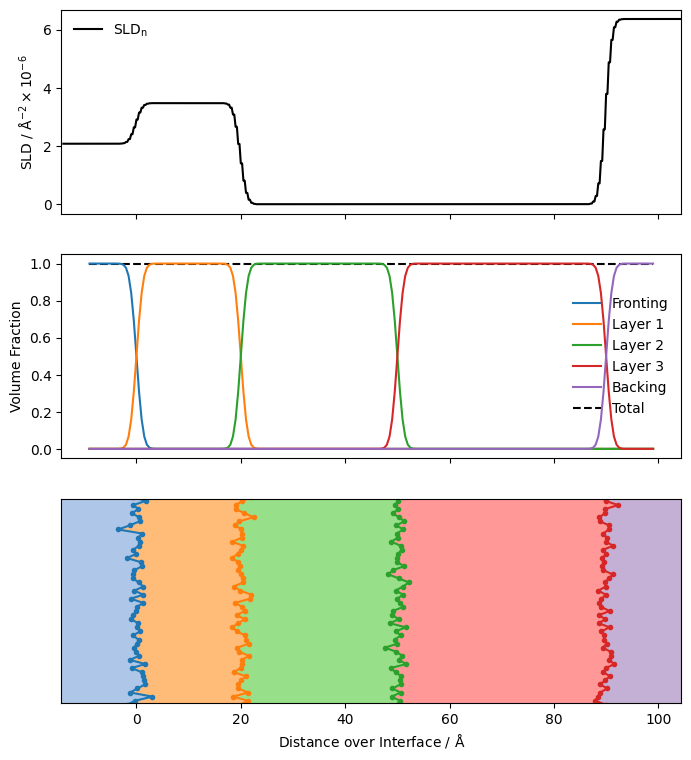

In [71]:
## Note: this might need updating with new plotting features.
t1_vfp.plot()
plt.show()

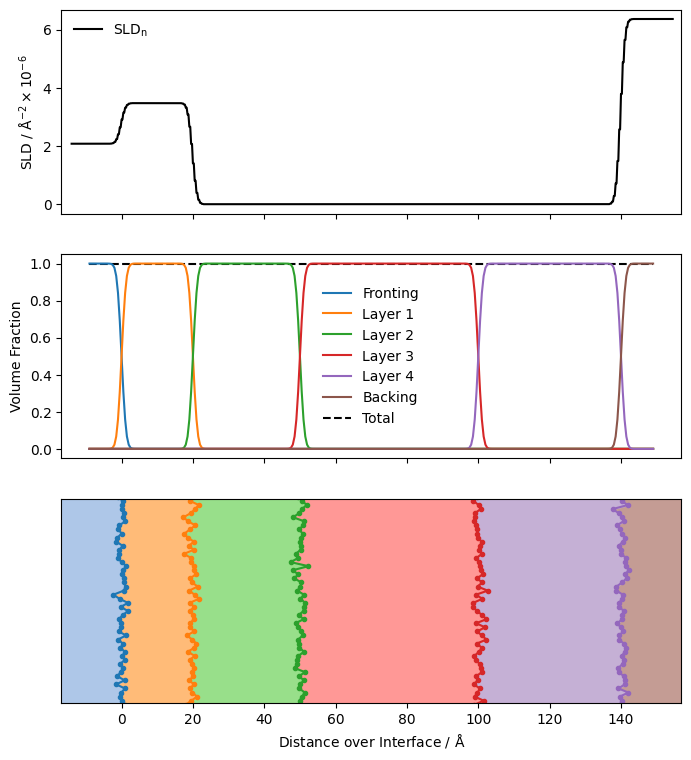

In [72]:
t2_vfp.plot()
plt.show()